# MET-MAP on BC-515: from scratch

MET-MAP models metabolic variation with three latent spatial gradients and a linear decoder with L1 regularization. The published workflow is adapted here to BC-515; the original small-intestine and liver analyses are not reproduced.

The model and training loop are implemented below using NumPy, scikit-learn, and PyTorch.

Run all cells using a Python environment with the dependencies listed in the README. Each implementation writes to its own results directory.

In [1]:
from pathlib import Path
import os, sys, json, time, hashlib, platform, importlib.metadata
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
import numpy as np
import pandas as pd
import anndata as ad
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / '01_METMAP_library.ipynb').is_file()
             and (p / 'vendor').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter from the METMAP-SIGMA-Tutorials folder or one of its subdirectories.')
HERE = DEMO = ROOT
INPUT = Path(os.environ.get('BC515_DATA', HERE / 'data/BC_515_Section_1.h5ad')).expanduser().resolve()
if not INPUT.is_file():
    raise FileNotFoundError('Place BC_515_Section_1.h5ad in data/ or set BC515_DATA. See DATA.md.')
OUT = DEMO / 'results/metmap_from_scratch'
OUT.mkdir(parents=True, exist_ok=True)
SEED, EPOCHS, K = 0, 3000, 3
CONFIG = dict(seed=SEED, epochs=EPOCHS, K=K, spatial_hidden=[120,120],
              expression_hidden=[], A_linear=True, lasso_lambda=0.0001,
              optimizer='Adam', lr=0.001, weight_decay=0.0, batch_size=None,
              schedule='LinearLR', end_factor=0.05, total_iters=12000,
              loss_threshold=-1.0, device='cpu', threads=1)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi':110, 'font.size':10, 'axes.spines.top':False,
                    'axes.spines.right':False, 'svg.fonttype':'none', 'pdf.fonttype':42})
print('Python', platform.python_version(), '| PyTorch', torch.__version__)
display(pd.Series(CONFIG, name='MET-MAP settings').to_frame())

Python 3.11.13 | PyTorch 2.2.2


,MET-MAP settings
seed,0
epochs,3000
K,3
spatial_hidden,"[120, 120]"
expression_hidden,[]
A_linear,True
lasso_lambda,0.0001
optimizer,Adam
lr,0.001
weight_decay,0.0


## 1. Input data

The metabolite matrix is stored in `adata.uns['msi']`; `adata.X` contains transcriptomic data. All 3,508 spatial spots and 2,086 metabolite features are retained.

Instrument TIC is unavailable. The sum of measured features per spot provides an approximate TIC for normalization:

\(A_{ij}=\log(1+X_{ij}/\mathrm{TIC}_i\times\overline{\mathrm{TIC}})\).

Coordinates and log-normalized intensities are standardized before fitting. Tumor/Stroma labels are shown for reference and are not used for training, tuning, or gradient orientation.

,quantity,value
0,spatial spots,3508
1,metabolite features,2086
2,excluded spots,0
3,excluded features,0


,n_spots
annotation,
Stroma,2707
Tumor,724
Unlabelled,77


Input SHA256: 1f96d6f1aaa36c117ccd7fb94b172a1c1435585d54279e8cffb93df0299c7204


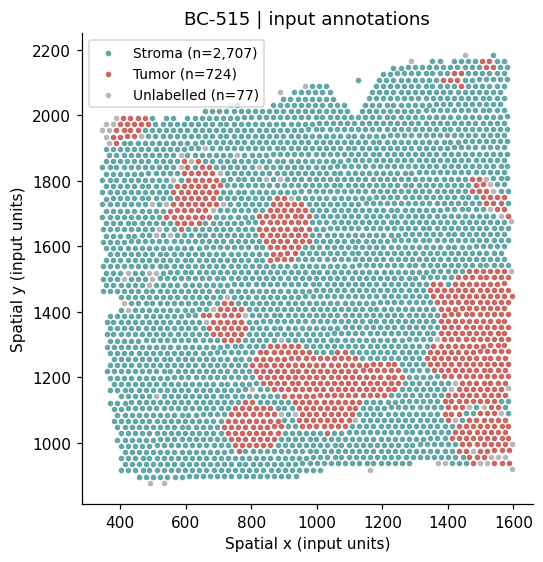

In [2]:
INPUT = Path(os.environ.get('BC515_DATA', HERE / 'data/BC_515_Section_1.h5ad')).expanduser().resolve()
INPUT_SHA256 = hashlib.sha256(INPUT.read_bytes()).hexdigest()
adata = ad.read_h5ad(INPUT)
X_raw = np.asarray(adata.uns['msi'], dtype=np.float64)
coords = np.asarray(adata.obsm['spatial'], dtype=np.float64)
mz = np.asarray(adata.uns['mz_features']).astype(str)
obs_names = adata.obs_names.to_numpy(dtype=str)
annotation = adata.obs['annotation'].astype(str).to_numpy()
assert X_raw.shape == (adata.n_obs, len(mz))
assert coords.shape == (adata.n_obs, 2) and len(np.unique(obs_names)) == len(obs_names)
assert np.isfinite(X_raw).all() and (X_raw >= 0).all() and np.isfinite(coords).all()
tic = X_raw.sum(axis=1)
assert (tic > 0).all(), 'Zero TIC values were found. Define how to preprocess these spots before proceeding.'
X_log = np.log1p(X_raw / tic[:,None] * tic.mean())
display(pd.DataFrame({'quantity':['spatial spots','metabolite features','excluded spots','excluded features'],
                      'value':[len(coords),X_raw.shape[1],0,0]}))
display(adata.obs['annotation'].value_counts().rename('n_spots').to_frame())
print('Input SHA256:', INPUT_SHA256)

fig, ax = plt.subplots(figsize=(6.4,5.0), constrained_layout=True)
palette = {'Tumor':'#c96862','Stroma':'#62a6a5','Unlabelled':'#b8b8b8'}
for label in pd.unique(annotation):
    keep = annotation == label
    ax.scatter(coords[keep,0],coords[keep,1],s=7,color=palette.get(label,'#aaaaaa'),
               label=f'{label} (n={keep.sum():,})',rasterized=True)
ax.set(xlabel='Spatial x (input units)',ylabel='Spatial y (input units)',title='BC-515 | input annotations')
ax.set_aspect('equal'); ax.legend(fontsize=9,loc='best')
fig.savefig(OUT/'input_annotations.png',dpi=180)
plt.show()

## 2. Model implementation

The encoder \(z=f_\theta(x,y)\) is a ReLU network with dimensions `2 → 120 → 120 → 3`. The decoder \(\hat a_i=Wz_i+b\) is a linear layer.

The objective is mean squared error over all spots and features plus `0.0001 × ||W||₁` applied to the decoder weights. Bias terms are unpenalized. Preprocessing, layer order, initialization, Adam updates, and the learning-rate schedule match the library implementation.

In [3]:
# Match the standardization used by tensor_transform_inputs.
feature_scaler = StandardScaler().fit(X_log)
spatial_scaler = StandardScaler().fit(coords)
A_tensor = torch.tensor(feature_scaler.transform(X_log), dtype=torch.float32)
S_tensor = torch.tensor(spatial_scaler.transform(coords), dtype=torch.float32)

class METMAPFromScratch(nn.Module):
    def __init__(self, n_features, n_depths=3):
        super().__init__()
        self.spatial_embedding = nn.Sequential(
            nn.Linear(2,120), nn.ReLU(), nn.Linear(120,120), nn.ReLU(),
            nn.Linear(120,n_depths))
        self.expression_function = nn.Sequential(nn.Linear(n_depths,n_features))

    def forward(self, spatial):
        return self.expression_function(self.spatial_embedding(spatial))

def train_from_scratch(spatial, abundance, settings):
    torch.manual_seed(settings['seed'])
    fitted = METMAPFromScratch(abundance.shape[1], settings['K'])
    optimizer = torch.optim.Adam(fitted.parameters(), lr=settings['lr'],
                                 weight_decay=settings['weight_decay'])
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1, end_factor=settings['end_factor'],
        total_iters=settings['total_iters'])
    total_losses = np.zeros(settings['epochs'])
    l1_losses = np.zeros(settings['epochs'])
    spatial.requires_grad_()
    for epoch in range(settings['epochs']):
        optimizer.zero_grad()
        mse = nn.functional.mse_loss(fitted(spatial), abundance, reduction='mean')
        l1 = settings['lasso_lambda'] * torch.norm(fitted.expression_function[0].weight, 1)
        objective = mse + l1
        total_losses[epoch] = objective.item()
        l1_losses[epoch] = l1.item()
        objective.backward()
        optimizer.step()
        scheduler.step()
        if (epoch+1) % 500 == 0:
            print(f'Epoch {epoch+1:4d} | total={objective.item():.6f} | MSE={mse.item():.6f}',flush=True)
    return fitted, total_losses, l1_losses

## 3. Training

The loss trace records the objective before each parameter update. The summary reports reconstruction MSE after the final update. A fixed seed and single-threaded CPU execution make runs comparable within the same environment.

Epoch  500 | total=0.877824 | MSE=0.854576


Epoch 1000 | total=0.832311 | MSE=0.820758


Epoch 1500 | total=0.820737 | MSE=0.809883


Epoch 2000 | total=0.811694 | MSE=0.801114


Epoch 2500 | total=0.807420 | MSE=0.798132


Epoch 3000 | total=0.804907 | MSE=0.796657


,result
spots,3508.000000
features,2086.000000
gradients,3.000000
epochs,3000.000000
first_total_loss,1.294701
last_logged_total_loss,0.804907
final_reconstruction_MSE,0.796654
elapsed_seconds,332.190934


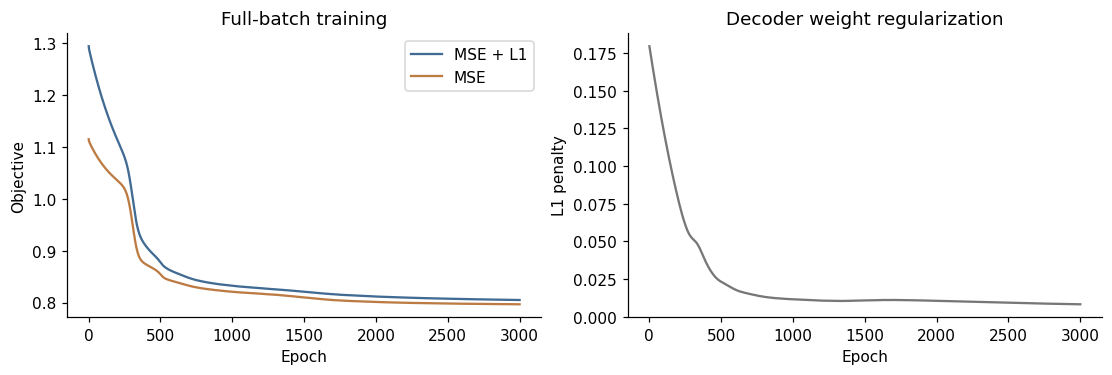

In [4]:
started = time.perf_counter()
model, total_losses, l1_losses = train_from_scratch(S_tensor, A_tensor, CONFIG)
elapsed = time.perf_counter() - started
model.eval()
with torch.no_grad():
    depth = model.spatial_embedding(S_tensor).cpu().numpy()
    prediction = model(S_tensor).cpu().numpy()
    weights = model.expression_function[0].weight.cpu().numpy()
target = A_tensor.detach().cpu().numpy()
assert len(total_losses) == EPOCHS and np.isfinite(depth).all() and np.isfinite(prediction).all()
final_mse = float(np.mean((prediction-target)**2))
summary = pd.Series({'spots':len(coords),'features':len(mz),'gradients':K,'epochs':EPOCHS,
    'first_total_loss':float(total_losses[0]),'last_logged_total_loss':float(total_losses[-1]),
    'final_reconstruction_MSE':final_mse,'elapsed_seconds':elapsed},name='result')
display(summary.to_frame())
loss_table = pd.DataFrame({'epoch':np.arange(1,EPOCHS+1),'total_loss':total_losses,
                           'reconstruction_MSE':total_losses-l1_losses,'L1_penalty':l1_losses})
loss_table.to_csv(OUT/'training_loss.csv',index=False)
fig, axes = plt.subplots(1,2,figsize=(10,3.3),constrained_layout=True)
axes[0].plot(loss_table.epoch,total_losses,color='#416b93',label='MSE + L1')
axes[0].plot(loss_table.epoch,total_losses-l1_losses,color='#bd7b44',label='MSE')
axes[0].set(xlabel='Epoch',ylabel='Objective',title='Full-batch training'); axes[0].legend()
axes[1].plot(loss_table.epoch,l1_losses,color='#777777')
axes[1].set(xlabel='Epoch',ylabel='L1 penalty',title='Decoder weight regularization')
fig.savefig(OUT/'training_loss.png',dpi=180)
plt.show()

## 4. Spatial gradients

Each gradient is scaled independently to [0,1] for display; saved outputs retain the raw isodepth values. Axis order, sign, and scale are not biologically identifiable. The gradients describe metabolic variation, not tumor boundaries or physical distance.

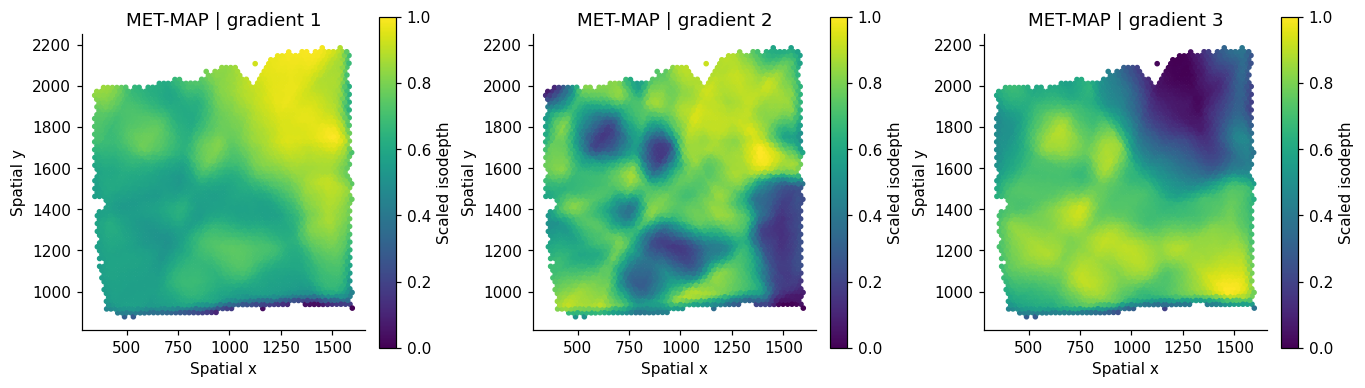

In [5]:
depth_display = (depth-depth.min(axis=0))/(np.ptp(depth,axis=0)+1e-12)
fig, axes = plt.subplots(1,K,figsize=(12.3,4.1),constrained_layout=True)
for k,ax in enumerate(axes):
    points=ax.scatter(coords[:,0],coords[:,1],c=depth_display[:,k],s=7,cmap='viridis',
                      vmin=0,vmax=1,rasterized=True)
    ax.set_aspect('equal'); ax.set(xlabel='Spatial x',ylabel='Spatial y',title=f'MET-MAP | gradient {k+1}')
    fig.colorbar(points,ax=ax,shrink=.75,label='Scaled isodepth')
fig.savefig(OUT/'spatial_gradients.png',dpi=180)
fig.savefig(OUT/'spatial_gradients.svg')
plt.show()

## 5. Metabolite reconstruction

Metabolites are ranked by training reconstruction \(R^2=1-\mathrm{SSE}/\mathrm{SST}\), retaining negative values. Scale-adjusted decoder loadings are calculated as `|decoder weight| × SD(isodepth)`. The three highest-ranked metabolites are shown below.

These are in-sample fit diagnostics. No independent test set or significance test is used.

,feature_index,mz,reconstruction_r2,strongest_gradient,scaled_loading_1,scaled_loading_2,scaled_loading_3
0,283,293.04799360362523,0.887339,2,0.039624,0.877104,0.094778
1,128,170.94415939231573,0.881173,2,0.003384,0.927867,0.006112
2,118,167.02066715378294,0.874188,2,0.020340,0.975795,0.077768
3,34,215.03197480143166,0.872258,2,0.088871,0.951060,0.073771
4,26,222.91955712871126,0.871803,2,0.330594,0.675355,0.420020
5,49,269.0865624380696,0.870915,2,0.001269,0.922816,0.004689
6,39,282.9768269041245,0.870776,2,0.313030,0.677118,0.415109
7,396,322.8555151999881,0.869563,2,0.044742,0.864434,0.070204
8,193,268.8009275633501,0.869014,2,0.061266,0.859273,0.070130
9,439,320.86042084661733,0.868084,2,0.016179,0.848796,0.101935


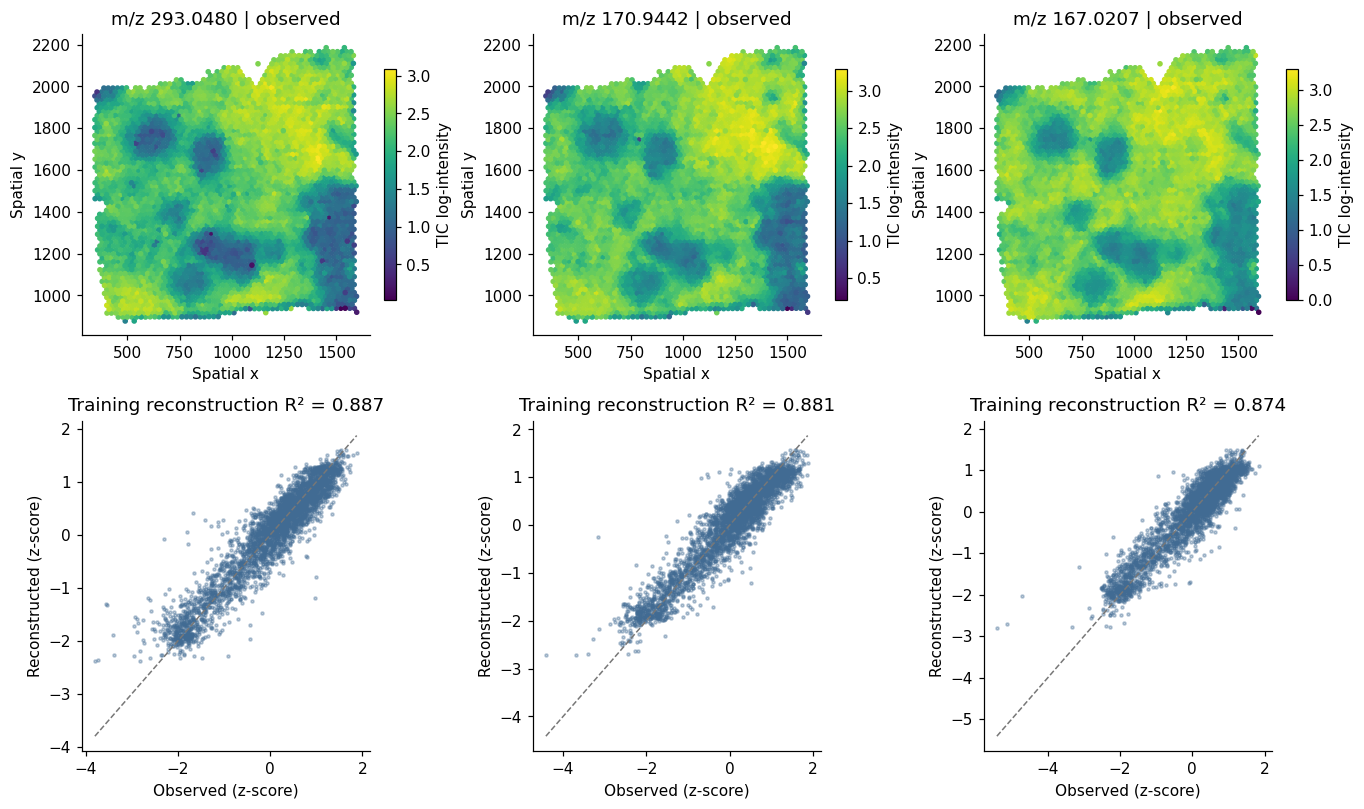

In [6]:
ss_total = np.sum((target-target.mean(axis=0))**2,axis=0)
ss_residual = np.sum((target-prediction)**2,axis=0)
r2 = np.full(len(mz),np.nan)
np.divide(ss_residual,ss_total,out=r2,where=ss_total>0)
r2 = 1-r2
loadings = np.abs(weights)*depth.std(axis=0,ddof=0)[None,:]
ranking = pd.DataFrame({'feature_index':np.arange(len(mz)),'mz':mz,'reconstruction_r2':r2,
                        'strongest_gradient':loadings.argmax(axis=1)+1})
for k in range(K): ranking[f'scaled_loading_{k+1}'] = loadings[:,k]
ranking = ranking.sort_values('reconstruction_r2',ascending=False,kind='stable').reset_index(drop=True)
display(ranking.head(10))
ranking.to_csv(OUT/'metabolite_ranking.csv',index=False)
top = ranking.head(3).feature_index.to_numpy(dtype=int)
fig, axes = plt.subplots(2,3,figsize=(12.3,7.3),constrained_layout=True)
for col,j in enumerate(top):
    point=axes[0,col].scatter(coords[:,0],coords[:,1],c=X_log[:,j],s=7,cmap='viridis',rasterized=True)
    axes[0,col].set_aspect('equal')
    axes[0,col].set(xlabel='Spatial x',ylabel='Spatial y',title=f'm/z {float(mz[j]):.4f} | observed')
    fig.colorbar(point,ax=axes[0,col],shrink=.7,label='TIC log-intensity')
    axes[1,col].scatter(target[:,j],prediction[:,j],s=4,alpha=.35,color='#416b93',rasterized=True)
    limits=[float(min(target[:,j].min(),prediction[:,j].min())),float(max(target[:,j].max(),prediction[:,j].max()))]
    axes[1,col].plot(limits,limits,color='#777777',lw=1,ls='--')
    axes[1,col].set(xlabel='Observed (z-score)',ylabel='Reconstructed (z-score)',title=f'Training reconstruction R² = {r2[j]:.3f}')
fig.savefig(OUT/'representative_metabolites.png',dpi=180)
plt.show()

## 6. Gradient profile

The highest-ranked metabolite is profiled along the axis with its largest scale-adjusted loading. Points show mean intensity in 20 equal-frequency bins; error bars show the SEM across spots in each bin. Spatial spots are not independent biological replicates, so SEM is descriptive and does not establish significance. The other two latent axes are not held fixed.

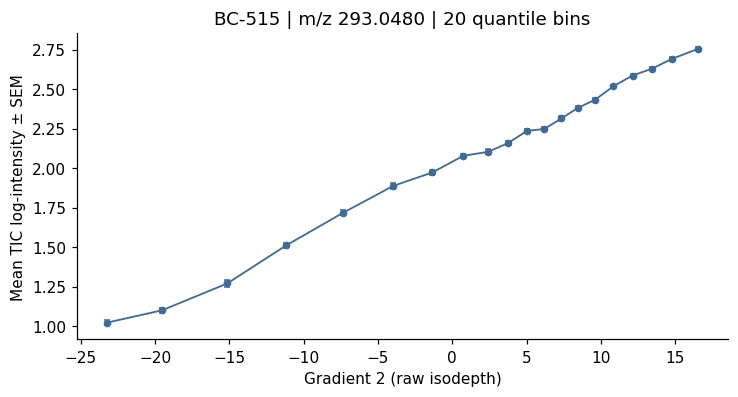

In [7]:
j=int(top[0]); k=int(loadings[j].argmax())
bins=pd.qcut(depth[:,k],q=20,duplicates='drop')
frame=pd.DataFrame({'bin':bins,'depth':depth[:,k],'intensity':X_log[:,j]})
profile=frame.groupby('bin',observed=True).agg(depth=('depth','mean'),mean=('intensity','mean'),
               std=('intensity','std'),n=('intensity','size')).reset_index(drop=True)
profile['sem']=profile['std']/np.sqrt(profile['n'])
profile.to_csv(OUT/'representative_gradient_profile.csv',index=False)
fig,ax=plt.subplots(figsize=(6.6,3.5),constrained_layout=True)
ax.errorbar(profile.depth,profile['mean'],yerr=profile['sem'],fmt='o-',ms=4,
            color='#416b93',capsize=2,lw=1.2)
ax.set(xlabel=f'Gradient {k+1} (raw isodepth)',ylabel='Mean TIC log-intensity ± SEM',
       title=f'BC-515 | m/z {float(mz[j]):.4f} | 20 quantile bins')
fig.savefig(OUT/'gradient_profile.png',dpi=180)
plt.show()

In [8]:
coordinate_table = pd.DataFrame({'obs_name':obs_names,'x':coords[:,0],'y':coords[:,1]})
for k in range(K): coordinate_table[f'isodepth_{k+1}']=depth[:,k]
coordinate_table.to_csv(OUT/'spatial_coordinates.csv',index=False)
np.savez_compressed(OUT/'outputs.npz',obs_names=obs_names,coords=coords,mz=mz,
                    depth=depth,weights=weights,loss=total_losses,r2=r2,
                    reconstruction=prediction,config_json=json.dumps(CONFIG,sort_keys=True),
                    input_sha256=INPUT_SHA256)
torch.save(model.state_dict(),OUT/'model_state_dict.pt')
metadata={'method':'MET-MAP','implementation':'from_scratch','input':str(INPUT.relative_to(ROOT)) if INPUT.is_relative_to(ROOT) else INPUT.name,
          'input_sha256':INPUT_SHA256,'config':CONFIG,'n_spots':len(coords),'n_features':len(mz),
          'excluded_spots':0,'excluded_features':0,'final_mse':final_mse,'elapsed_seconds':elapsed,
          'source_commit':'43c9386ffe7d5b2f0f66d64d4820358c3cd8a11c',
          'source_sha256':globals().get('SOURCE_HASH'),
          'normalization':'measured-feature row-sum TIC; mean TIC scaling; log1p; feature z-score',
          'versions':{p:importlib.metadata.version(p) for p in ['numpy','scipy','pandas','scikit-learn','torch','anndata','matplotlib']}}
(OUT/'provenance.json').write_text(json.dumps(metadata,indent=2,ensure_ascii=False))
print('Saved:',OUT.relative_to(ROOT))

Saved: notebooks/BC515_four_implementations/results/metmap_from_scratch


## 7. Implementation check

When companion results are available, this cell compares input hashes, settings, spot order, losses, gradients, decoder weights, and reconstructions. Matching runs should agree within numerical tolerance.

In [9]:
other_path=DEMO/'results/metmap_library/outputs.npz'
if other_path.exists():
    with np.load(other_path,allow_pickle=False) as other:
        assert str(other['input_sha256']) == INPUT_SHA256, 'The input hashes differ. Rerun the companion notebook.'
        assert str(other['config_json']) == json.dumps(CONFIG,sort_keys=True), 'The two implementations use different settings.'
        assert np.array_equal(obs_names,other['obs_names']) and np.array_equal(mz,other['mz'])
        checks=[]
        for field,value in [('coords',coords),('depth',depth),('weights',weights),
                            ('loss',total_losses),('r2',r2),('reconstruction',prediction)]:
            reference=other[field]
            delta=float(np.nanmax(np.abs(value-reference)))
            same=bool(np.allclose(value,reference,rtol=1e-6,atol=1e-6,equal_nan=True))
            checks.append({'field':field,'max_absolute_difference':delta,'pass':same})
        checks=pd.DataFrame(checks)
        display(checks)
        checks.to_csv(OUT/'implementation_parity.csv',index=False)
        assert checks['pass'].all(), 'The implementation outputs do not agree. Inspect the differences.'
else:
    print('Companion MET-MAP results are unavailable. Run the companion notebook and rerun this cell to compare outputs.')

,field,max_absolute_difference,pass
0,coords,0.0,True
1,depth,0.0,True
2,weights,0.0,True
3,loss,0.0,True
4,r2,0.0,True
5,reconstruction,0.0,True


## Source

[raphael-group/MET-MAP](https://github.com/raphael-group/MET-MAP), commit `43c9386ffe7d5b2f0f66d64d4820358c3cd8a11c`.

The implementation follows `src/multi_gaston/multi_gaston.py` and the upstream multi-gradient tutorial.

### Upstream license

```text
BSD 3-Clause License

Copyright (c) 2025, raphael-group

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

3. Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

```